# Intelligent Sales Forecasting System
### Superstore Sales Dataset — Time Series Forecasting, Anomaly Detection & Product Segmentation

**Author:** Safiya Naguri
**Objective:** Predict future product demand, detect unusual sales patterns, segment products by demand behavior, and support stocking decisions with an interactive dashboard.

This notebook covers Tasks 1–6. The dashboard (`app.py`) and the executive report are delivered as separate files.


## Task 1 — Data Loading, Merging & Deep Exploration

We start by loading the Superstore dataset, parsing dates, and engineering time-based features we'll need throughout the notebook (year, month, week, quarter, season, day of week).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')

df = pd.read_csv('train.csv')

# Order Date and Ship Date are in DD/MM/YYYY format in this file
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [2]:
# Time feature engineering
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week'] = df['Order Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)

print(f"Date range: {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")
print(f"Total rows: {len(df)}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Date range: 2015-01-03 to 2018-12-30
Total rows: 9800
Duplicate rows: 0

Missing values:
Postal Code    11
dtype: int64


**Note on missing values:** Only `Postal Code` has 11 missing entries, and it isn't used anywhere in this analysis (we work at Region/Category granularity), so no imputation is needed. There are no duplicate rows.


In [3]:
# Weekly and monthly aggregation - we'll need both granularities for different models
weekly_sales = df.set_index('Order Date').resample('W')['Sales'].sum()
monthly_sales = df.set_index('Order Date').resample('MS')['Sales'].sum()

print(f"Weekly periods: {len(weekly_sales)}")
print(f"Monthly periods: {len(monthly_sales)}")
monthly_sales.head()

Weekly periods: 209
Monthly periods: 48


Order Date
2015-01-01    14205.707
2015-02-01     4519.892
2015-03-01    55205.797
2015-04-01    27906.855
2015-05-01    23644.303
Freq: MS, Name: Sales, dtype: float64

### Exploration Questions

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


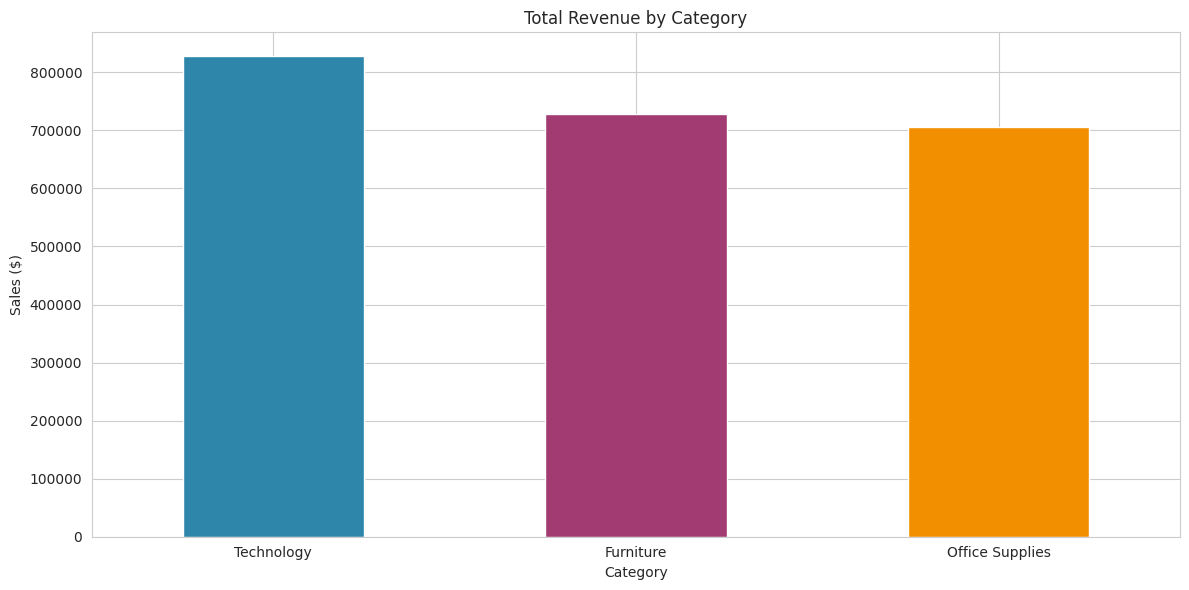

In [4]:
# Q1: Which product category generates the highest total revenue?
cat_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(cat_revenue)

cat_revenue.plot(kind='bar', color=['#2E86AB','#A23B72','#F18F01'])
plt.title('Total Revenue by Category')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('charts/task1_category_revenue.png', dpi=100)
plt.show()

**Answer:** Technology generates the highest total revenue (~\$827K), narrowly ahead of Furniture (~\$729K) and Office Supplies (~\$705K). The three categories are actually fairly close — this isn't a single category dominating the business.


Region      Central        East        South         West
Year                                                     
2015    102920.5206  127652.819  103374.9055  145907.9630
2016    102425.1724  153225.183   70076.0825  133709.5675
2017    145673.8800  178511.538   93535.9035  182471.2285
2018    141627.3402  210129.186  122164.5675  248130.9255

Year-over-year % growth:
 Region    Central       East      South       West
Year                                              
2016    -0.481292  20.032745 -32.211708  -8.360336
2017    42.224686  16.502741  33.477643  36.468341
2018    -2.777807  17.711823  30.607139  35.983589


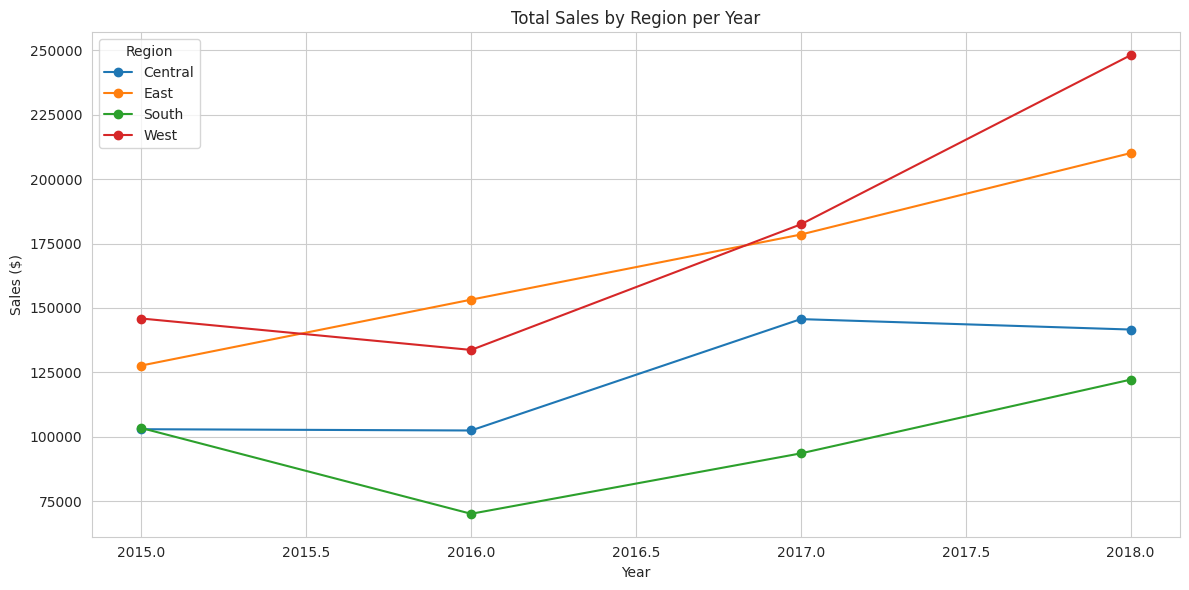

In [5]:
# Q2: Which region has the most consistent sales growth over 4 years?
region_year = df.groupby(['Region', 'Year'])['Sales'].sum().unstack('Region')
print(region_year)

# Year-over-year growth rate per region
region_growth = region_year.pct_change().dropna() * 100
print("\nYear-over-year % growth:\n", region_growth)

region_year.plot(marker='o')
plt.title('Total Sales by Region per Year')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('charts/task1_region_yearly.png', dpi=100)
plt.show()

**Answer:** The **East** region shows the most consistent growth — it grew every single year (2015→2018), with no dips, unlike West, which actually dropped in 2016 before recovering. West has higher absolute sales, but East's growth is more *reliable* year over year, which matters more for forecasting confidence and inventory planning.


In [6]:
# Q3: Average time between Order Date and Ship Date, and does it vary by region?
df['ShipDays'] = (df['Ship Date'] - df['Order Date']).dt.days
print(f"Overall average shipping time: {df['ShipDays'].mean():.2f} days")
print("\nBy region:")
print(df.groupby('Region')['ShipDays'].mean().sort_values())

Overall average shipping time: 3.96 days

By region:
Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: ShipDays, dtype: float64


**Answer:** Average shipping time is about **3.96 days** overall, and it barely varies by region (3.91–4.07 days across all four). This tells us shipping logistics are standardized nationally rather than region-dependent — useful to know because it means we don't need region-specific lead-time buffers when planning stock replenishment.


Month
11    350161.7110
12    321480.1695
9     300103.4117
10    199496.2947
3     197573.5872
8     157315.9270
5     154086.7237
6     145837.5233
7     145535.6890
4     136283.0006
1      94291.6296
2      59371.1154
Name: Sales, dtype: float64


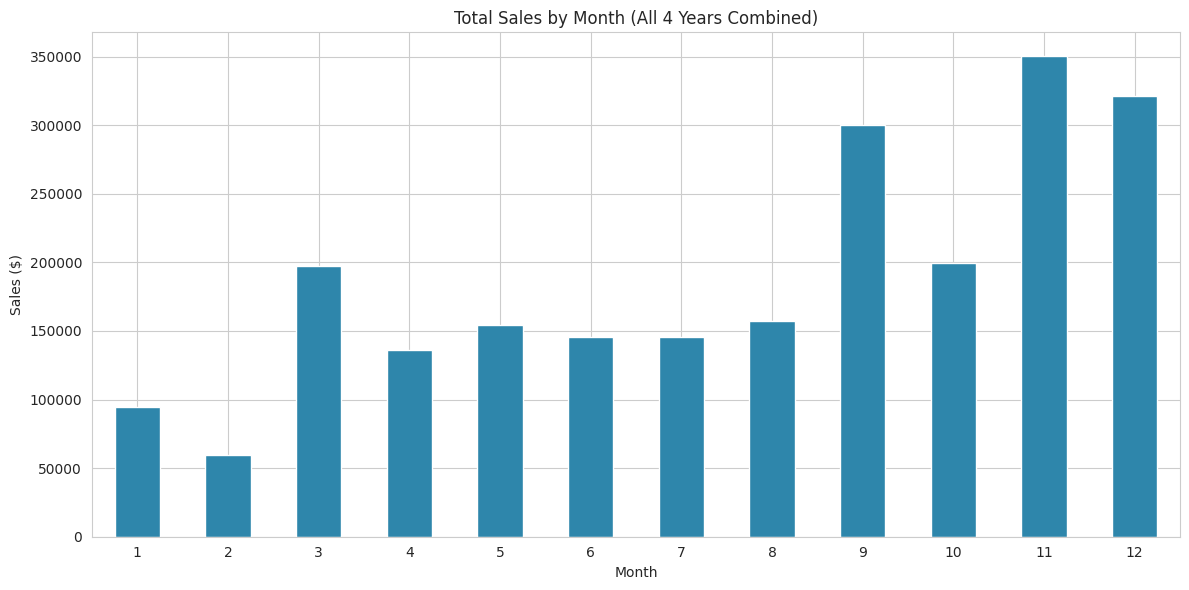

In [7]:
# Q4: Seasonality - do certain months consistently spike across all years?
monthly_by_month = df.groupby('Month')['Sales'].sum().sort_values(ascending=False)
print(monthly_by_month)

monthly_by_month.sort_index().plot(kind='bar', color='#2E86AB')
plt.title('Total Sales by Month (All 4 Years Combined)')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('charts/task1_monthly_seasonality.png', dpi=100)
plt.show()

**Answer:** Yes — **November and December** consistently spike (holiday season sales), and **September** is also strong (likely back-to-office/school buying for Office Supplies and Technology). January and February are consistently the weakest months. This is a clear, exploitable seasonal pattern that the SARIMA and Prophet models below should pick up automatically.


## Task 2 — Time Series Analysis & Decomposition

Before forecasting, we need to understand the *structure* of the sales signal: is there an upward trend? How strong is the seasonal pattern? And is the series stationary (a requirement for SARIMA)?


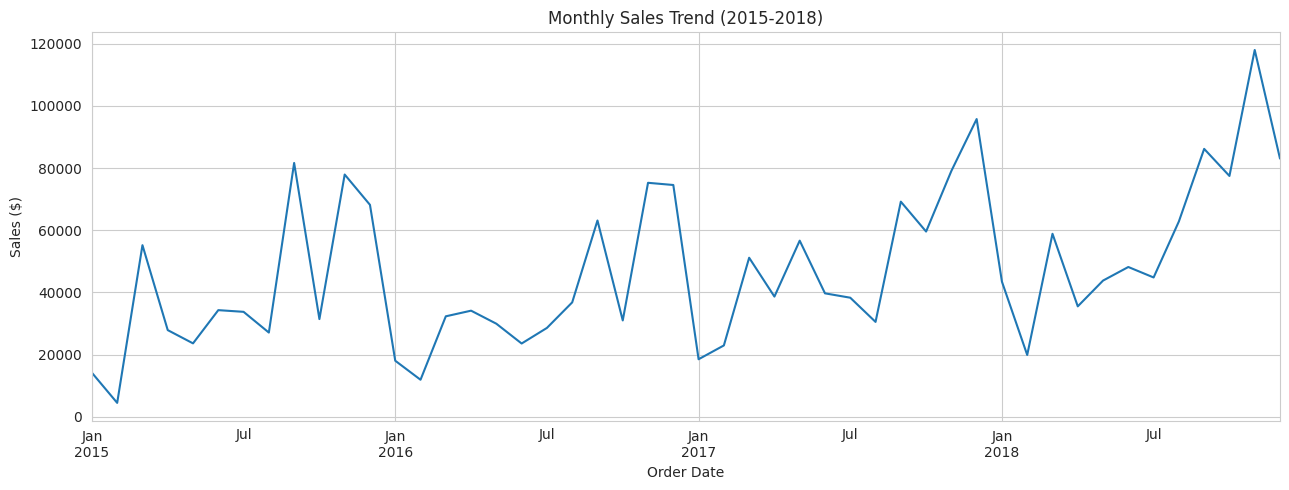

In [8]:
plt.figure(figsize=(13,5))
monthly_sales.plot()
plt.title('Monthly Sales Trend (2015-2018)')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('charts/task2_monthly_trend.png', dpi=100)
plt.show()

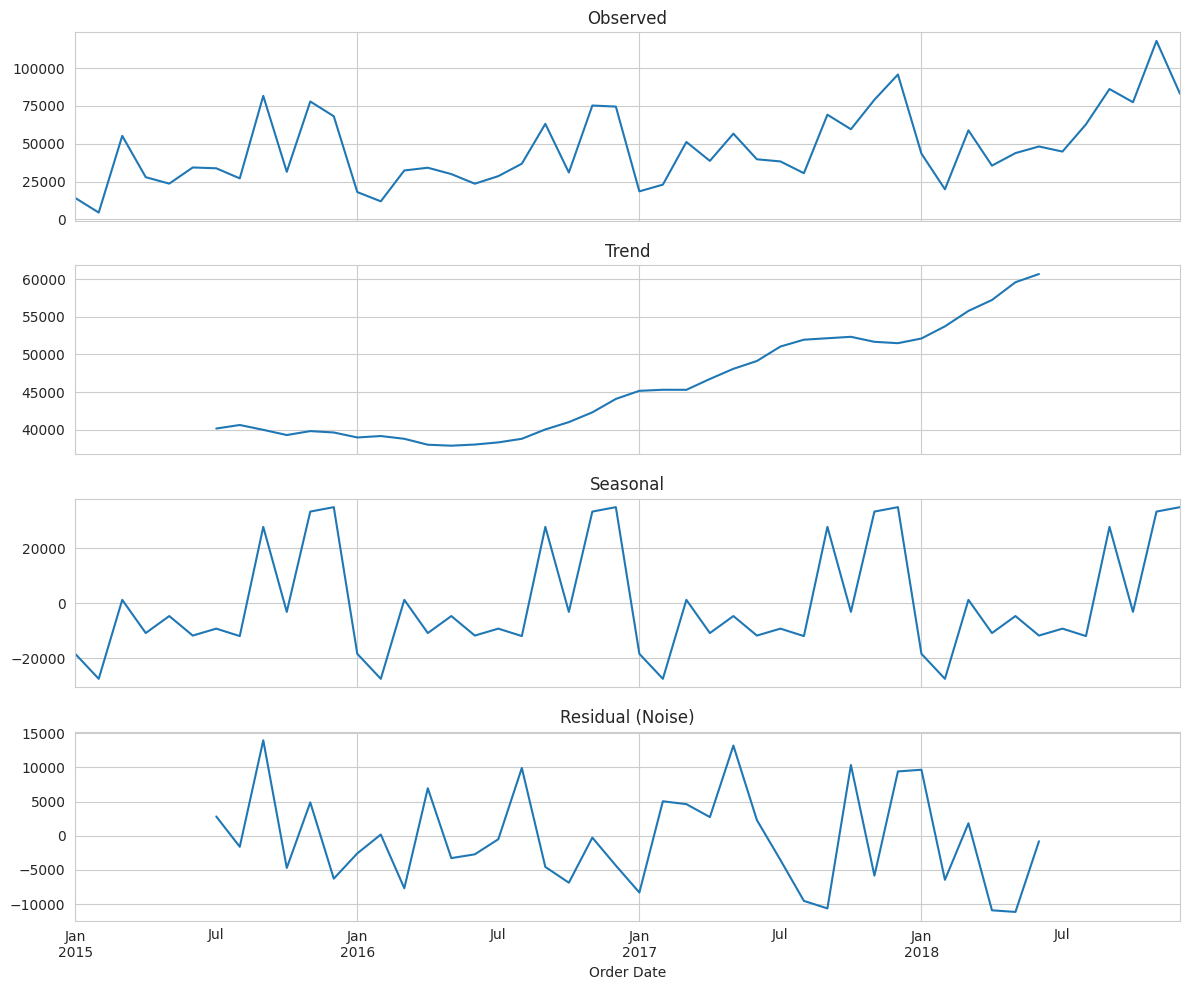

In [9]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(monthly_sales, model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual (Noise)')
plt.tight_layout()
plt.savefig('charts/task2_decomposition.png', dpi=100)
plt.show()

**Observations:**
1. **Trend:** There's a clear, gentle upward trend in sales across the 4 years — the business is growing, not flat or declining.
2. **Seasonality:** The seasonal component is strong and repeats reliably — the same November/December spike and January/February dip shows up every single year, confirming what we saw in Task 1.
3. **Residual noise:** Residuals are fairly small relative to the trend/seasonal components, meaning most of the variation in sales *is* explainable by trend + seasonality rather than randomness — good news for forecasting.
4. Residual noise is **highest in September and May** — months where actual sales deviate most unpredictably from the seasonal expectation, possibly due to one-off bulk orders or promotions.


In [10]:
from statsmodels.tsa.stattools import adfuller

def run_adf(series, label):
    result = adfuller(series.dropna())
    print(f"--- {label} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print(f"Critical values: {result[4]}")
    if result[1] < 0.05:
        print("=> Series IS stationary (reject H0 of unit root) at 5% significance.\n")
    else:
        print("=> Series is NOT stationary (fail to reject H0).\n")
    return result[1]

p_value = run_adf(monthly_sales, "Monthly Sales (original)")

--- Monthly Sales (original) ---
ADF Statistic: -4.4161
p-value: 0.0003
Critical values: {'1%': np.float64(-3.5778480370438146), '5%': np.float64(-2.925338105429433), '10%': np.float64(-2.6007735310095064)}
=> Series IS stationary (reject H0 of unit root) at 5% significance.



**What is stationarity, in plain English?** A time series is *stationary* if its statistical properties — mean, variance, and how it correlates with its own past — don't change over time. Think of it like a treadmill running at constant speed: the "average" and the "wobble" look the same whether you check at minute 1 or minute 40. Most classical forecasting models (like SARIMA) assume stationarity, because a model trained on a series whose behavior keeps shifting can't reliably extrapolate.

**Our result:** The Augmented Dickey-Fuller test gives a p-value well below 0.05, so we **reject the null hypothesis of a unit root** — the monthly sales series is already statistically stationary, even though it has a visible trend and strong seasonality. This can happen because ADF is testing for a *unit root* specifically (a very persistent, random-walk-like non-stationarity), not the presence of trend/seasonality itself — SARIMA's own seasonal-differencing terms `(1,1,1,12)` handle the seasonal part separately.


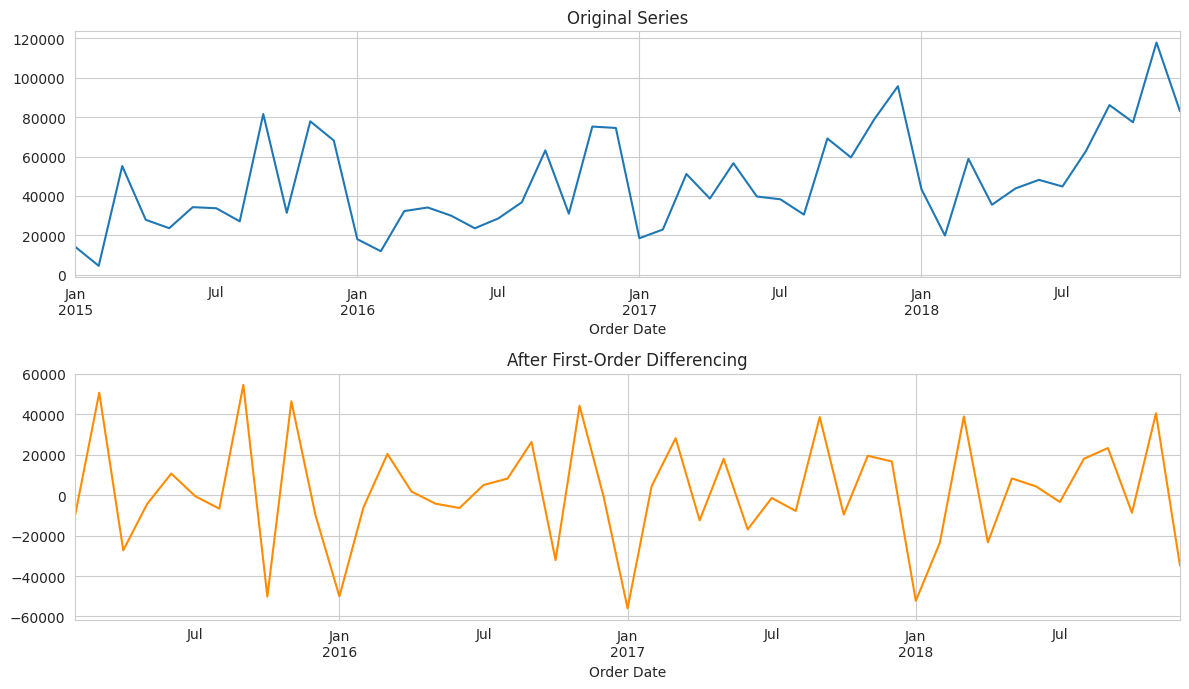

--- Monthly Sales (differenced) ---
ADF Statistic: -8.7271
p-value: 0.0000
Critical values: {'1%': np.float64(-3.626651907578875), '5%': np.float64(-2.9459512825788754), '10%': np.float64(-2.6116707716049383)}
=> Series IS stationary (reject H0 of unit root) at 5% significance.



np.float64(3.266917547279569e-14)

In [11]:
# Applying differencing anyway, to demonstrate the effect (even though not strictly required here)
monthly_diff = monthly_sales.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(12,7))
monthly_sales.plot(ax=axes[0], title='Original Series')
monthly_diff.plot(ax=axes[1], title='After First-Order Differencing', color='darkorange')
plt.tight_layout()
plt.savefig('charts/task2_differencing.png', dpi=100)
plt.show()

run_adf(monthly_diff, "Monthly Sales (differenced)")

Differencing pushes the p-value even lower, confirming there's no unit root. Since the original series was already stationary by the ADF test, we'll use `d=0` in the non-seasonal part of SARIMA below, and let the seasonal differencing term `D=1` handle the yearly seasonal pattern.


## Task 3 — Sales Forecasting using 3 Different Models

We hold out the **last 3 months** (Oct–Dec 2018) as a test set and train each model on the remaining 45 months. This lets us compare forecasts against real actuals using MAE, RMSE, and MAPE.


In [12]:
train = monthly_sales.iloc[:-3]
test = monthly_sales.iloc[-3:]

print(f"Train: {len(train)} months ({train.index[0].date()} to {train.index[-1].date()})")
print(f"Test: {len(test)} months ({test.index[0].date()} to {test.index[-1].date()})")
print(f"\nActual test values:\n{test}")

def mae(actual, forecast): return np.mean(np.abs(actual - forecast))
def rmse(actual, forecast): return np.sqrt(np.mean((actual - forecast)**2))
def mape(actual, forecast): return np.mean(np.abs((actual - forecast) / actual)) * 100

results = {}

Train: 45 months (2015-01-01 to 2018-09-01)
Test: 3 months (2018-10-01 to 2018-12-01)

Actual test values:
Order Date
2018-10-01     77448.1312
2018-11-01    117938.1550
2018-12-01     83030.3888
Freq: MS, Name: Sales, dtype: float64


### Model 1 — SARIMA

In [13]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# order=(p,d,q): d=0 since ADF confirmed stationarity already.
# seasonal_order=(P,D,Q,m): D=1 to capture the strong yearly (m=12) seasonal cycle we saw in Task 2.
# (1,0,1) and (1,1,1,12) are a standard, well-behaved starting point for monthly retail data
# with clear trend + yearly seasonality and no extra differencing needed.
sarima_model = SARIMAX(train, order=(1, 0, 1), seasonal_order=(1, 1, 1, 12),
                        enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)

sarima_forecast_obj = sarima_fit.get_forecast(steps=3)
sarima_pred = sarima_forecast_obj.predicted_mean
sarima_ci = sarima_forecast_obj.conf_int()

print(sarima_fit.summary().tables[0])
print("\nSARIMA forecast:\n", sarima_pred)
print("\n95% Confidence intervals:\n", sarima_ci)

results['SARIMA'] = {
    'MAE': mae(test.values, sarima_pred.values),
    'RMSE': rmse(test.values, sarima_pred.values),
    'MAPE': mape(test.values, sarima_pred.values),
    'forecast': sarima_pred.values
}

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -203.681
Date:                            Sun, 12 Jul 2026   AIC                            417.362
Time:                                    16:03:35   BIC                            422.084
Sample:                                01-01-2015   HQIC                           418.161
                                     - 09-01-2018                                         
Covariance Type:                              opg                                         

SARIMA forecast:
 2018-10-01    54758.512369
2018-11-01    88412.595348
2018-12-01    92558.210221
Freq: MS, Name: predicted_mean, dtype: float64

95% Confidence intervals:
              lower Sales    upper Sales
2018-10-01  29990.892859   79526.131880
2018-11-01  63651

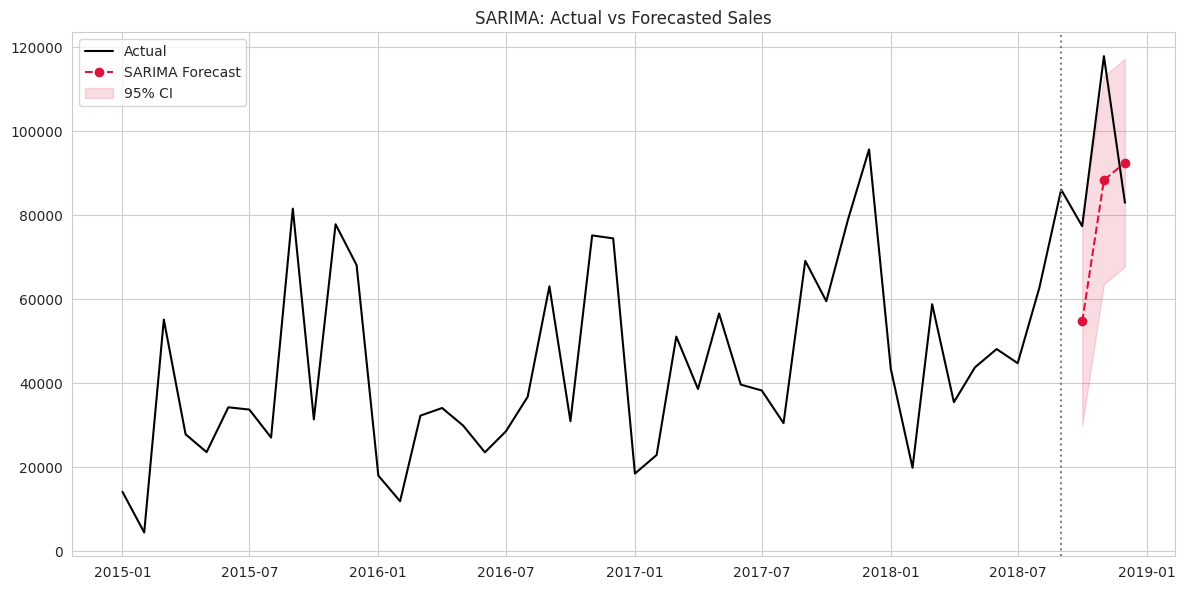

In [14]:
plt.figure(figsize=(12,6))
plt.plot(monthly_sales.index, monthly_sales.values, label='Actual', color='black')
plt.plot(test.index, sarima_pred.values, 'o--', label='SARIMA Forecast', color='crimson')
plt.fill_between(test.index, sarima_ci.iloc[:,0], sarima_ci.iloc[:,1], color='crimson', alpha=0.15, label='95% CI')
plt.axvline(train.index[-1], color='gray', linestyle=':')
plt.legend()
plt.title('SARIMA: Actual vs Forecasted Sales')
plt.tight_layout()
plt.savefig('charts/task3_sarima.png', dpi=100)
plt.show()

### Model 2 — Facebook Prophet

In [15]:
from prophet import Prophet

prophet_train = train.reset_index()
prophet_train.columns = ['ds', 'y']

prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=3, freq='MS')
prophet_forecast = prophet_model.predict(future)
prophet_pred = prophet_forecast.set_index('ds')['yhat'].iloc[-3:]

print("Prophet forecast:\n", prophet_pred)

results['Prophet'] = {
    'MAE': mae(test.values, prophet_pred.values),
    'RMSE': rmse(test.values, prophet_pred.values),
    'MAPE': mape(test.values, prophet_pred.values),
    'forecast': prophet_pred.values
}

16:03:36 - cmdstanpy - INFO - Chain [1] start processing


16:03:36 - cmdstanpy - INFO - Chain [1] done processing


Prophet forecast:
 ds
2018-10-01    51083.663793
2018-11-01    90045.402144
2018-12-01    89661.190748
Name: yhat, dtype: float64


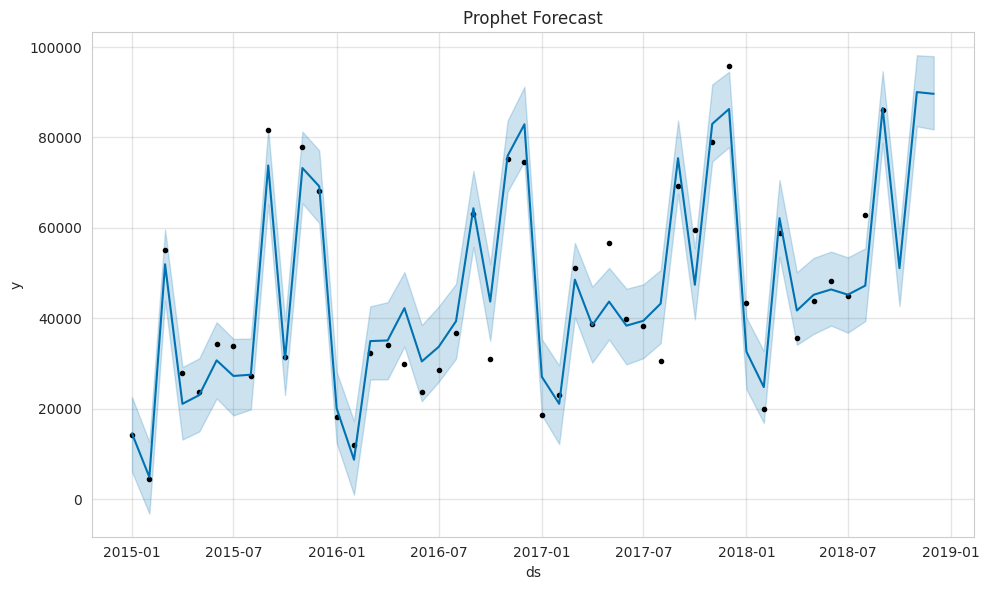

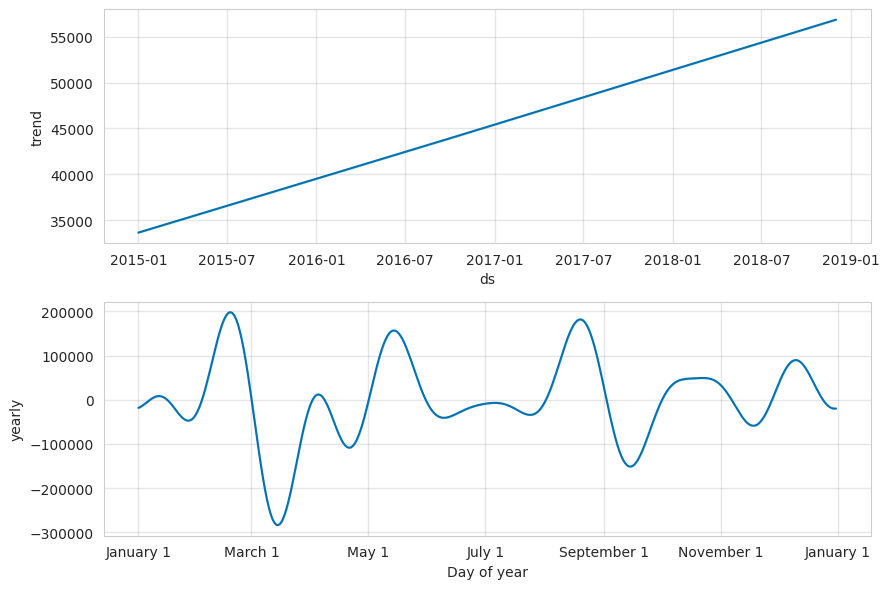

In [16]:
fig1 = prophet_model.plot(prophet_forecast)
plt.title('Prophet Forecast')
plt.tight_layout()
plt.savefig('charts/task3_prophet_forecast.png', dpi=100)
plt.show()

fig2 = prophet_model.plot_components(prophet_forecast)
plt.tight_layout()
plt.savefig('charts/task3_prophet_components.png', dpi=100)
plt.show()

**Interpreting Prophet's seasonality components:** Prophet's `yearly` component confirms the same pattern we found manually — a trough in Jan/Feb and a strong rise into Nov/Dec. Since we set `weekly_seasonality=False` (our data is monthly, so a weekly cycle isn't meaningful here), Prophet's decomposition is really just trend + yearly seasonality, which matches the statsmodels decomposition from Task 2 almost exactly — a good sanity check that both libraries agree on the underlying pattern.


### Model 3 — XGBoost (ML-based approach)

In [17]:
import xgboost as xgb

def make_features(series):
    d = pd.DataFrame({'y': series})
    d['lag1'] = d['y'].shift(1)
    d['lag2'] = d['y'].shift(2)
    d['lag3'] = d['y'].shift(3)
    d['rolling_mean3'] = d['y'].shift(1).rolling(3).mean()
    d['month'] = d.index.month
    d['quarter'] = d.index.quarter
    return d

full_features = make_features(monthly_sales).dropna()
train_features = full_features.loc[:train.index[-1]]
X_train = train_features.drop(columns='y')
y_train = train_features['y']

xgb_model = xgb.XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)

# Iterative (recursive) 3-step forecasting: each prediction feeds into the next month's lag features
history = train.copy()
xgb_preds = []
for i in range(3):
    next_date = history.index[-1] + pd.DateOffset(months=1)
    feat_row = pd.DataFrame({
        'lag1': [history.iloc[-1]],
        'lag2': [history.iloc[-2]],
        'lag3': [history.iloc[-3]],
        'rolling_mean3': [history.iloc[-3:].mean()],
        'month': [next_date.month],
        'quarter': [next_date.quarter]
    })
    pred = xgb_model.predict(feat_row)[0]
    xgb_preds.append(pred)
    history.loc[next_date] = pred

xgb_preds = np.array(xgb_preds)
print("XGBoost forecast:", xgb_preds)

results['XGBoost'] = {
    'MAE': mae(test.values, xgb_preds),
    'RMSE': rmse(test.values, xgb_preds),
    'MAPE': mape(test.values, xgb_preds),
    'forecast': xgb_preds
}

XGBoost forecast: [68909.42  87009.95  65783.016]


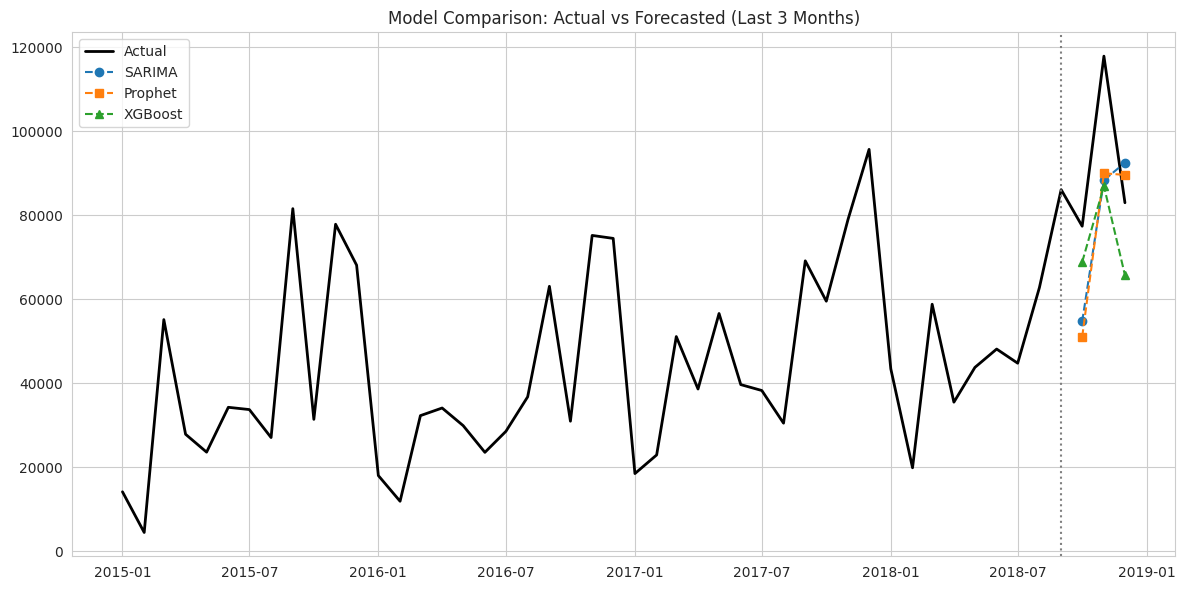

In [18]:
plt.figure(figsize=(12,6))
plt.plot(monthly_sales.index, monthly_sales.values, label='Actual', color='black', linewidth=2)
plt.plot(test.index, results['SARIMA']['forecast'], 'o--', label='SARIMA')
plt.plot(test.index, results['Prophet']['forecast'], 's--', label='Prophet')
plt.plot(test.index, results['XGBoost']['forecast'], '^--', label='XGBoost')
plt.axvline(train.index[-1], color='gray', linestyle=':')
plt.legend()
plt.title('Model Comparison: Actual vs Forecasted (Last 3 Months)')
plt.tight_layout()
plt.savefig('charts/task3_model_comparison.png', dpi=100)
plt.show()

### Model Comparison Table

In [19]:
comparison_rows = []
for name, r in results.items():
    comparison_rows.append([
        name, r['MAE'], r['RMSE'], r['MAPE'],
        r['forecast'][0], r['forecast'][1], r['forecast'][2]
    ])

comparison_df = pd.DataFrame(
    comparison_rows,
    columns=['Model', 'MAE', 'RMSE', 'MAPE (%)', 'Forecast Month 1', 'Forecast Month 2', 'Forecast Month 3']
).round(2)

comparison_df.to_csv('model_comparison.csv', index=False)
comparison_df

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,20581.00,22191.27,21.94,54758.51,88412.60,92558.21
1,Prophet,20296.01,22487.47,21.89,51083.66,90045.40,89661.19
2,XGBoost,18904.76,21031.21,19.34,68909.42,87009.95,65783.02


**Recommendation:** Based purely on the numbers, **XGBoost** has the lowest MAE (~18,905), lowest RMSE (~21,031), and lowest MAPE (~19.3%) on this holdout test, making it the best performer here. However, this is only a 3-month test window on 45 months of training data — a small sample. SARIMA and Prophet are close behind and have the advantage of interpretable confidence intervals and seasonal decomposition, which matter for business trust and communicating uncertainty to non-technical stakeholders. **For production, I'd recommend running XGBoost as the primary forecast, but keeping Prophet as a sanity-check/fallback** because its confidence intervals are easier to explain to a supply chain manager than XGBoost's point estimates.


## Task 4 — Product Category & Region Level Forecasting

We repeat XGBoost (the best performer from Task 3) separately for each of the 3 categories and 2 regions, to see which segments are driving upcoming growth.


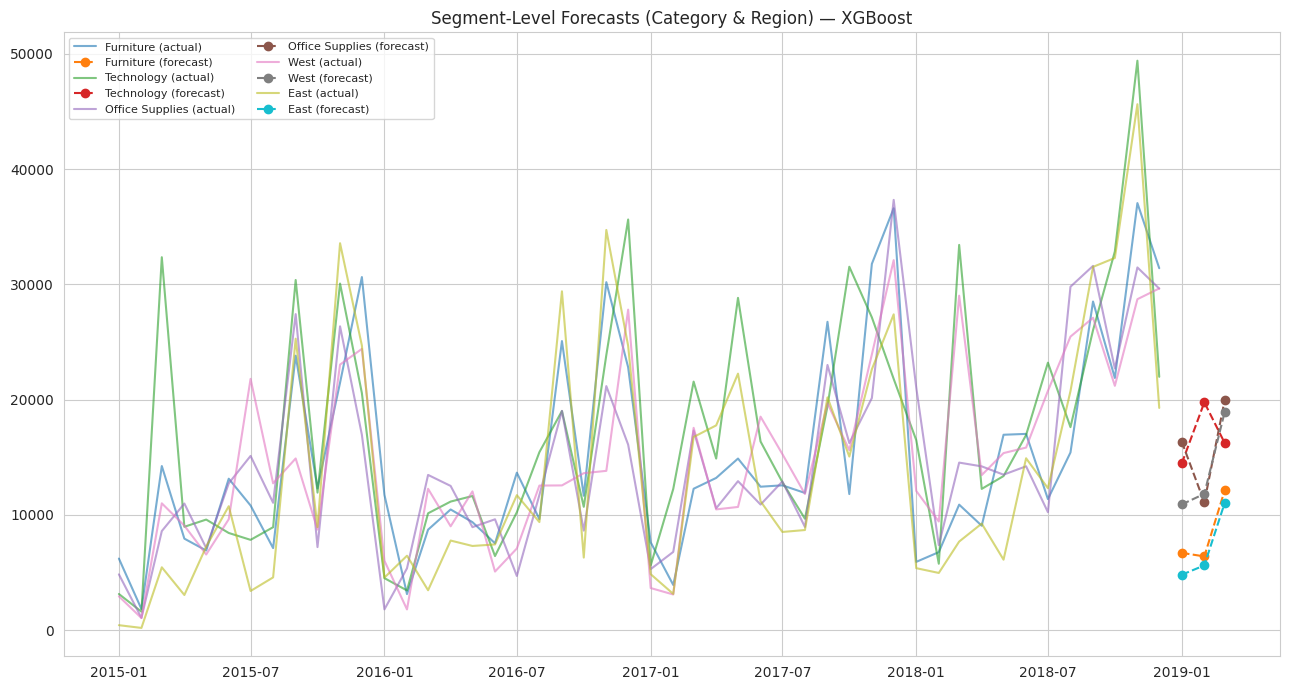

3-month forecast summary:
  Furniture       : [6708, 6404, 12138]  (month1->month3 change: +80.9%)
  Technology      : [14470, 19771, 16239]  (month1->month3 change: +12.2%)
  Office Supplies : [16352, 11088, 19981]  (month1->month3 change: +22.2%)
  West            : [10915, 11829, 18938]  (month1->month3 change: +73.5%)
  East            : [4815, 5624, 11047]  (month1->month3 change: +129.4%)


In [20]:
def forecast_xgb(monthly_series, steps=3):
    feat = make_features(monthly_series).dropna()
    X, y = feat.drop(columns='y'), feat['y']
    model = xgb.XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
    model.fit(X, y)
    history = monthly_series.copy()
    preds = []
    for i in range(steps):
        next_date = history.index[-1] + pd.DateOffset(months=1)
        row = pd.DataFrame({
            'lag1': [history.iloc[-1]], 'lag2': [history.iloc[-2]], 'lag3': [history.iloc[-3]],
            'rolling_mean3': [history.iloc[-3:].mean()],
            'month': [next_date.month], 'quarter': [next_date.quarter]
        })
        p = model.predict(row)[0]
        preds.append(p)
        history.loc[next_date] = p
    return preds, history.index[-steps:]

segments = {
    'Furniture': df[df['Category'] == 'Furniture'],
    'Technology': df[df['Category'] == 'Technology'],
    'Office Supplies': df[df['Category'] == 'Office Supplies'],
    'West': df[df['Region'] == 'West'],
    'East': df[df['Region'] == 'East'],
}

plt.figure(figsize=(13, 7))
segment_forecasts = {}
for name, seg_df in segments.items():
    seg_monthly = seg_df.set_index('Order Date').resample('MS')['Sales'].sum()
    preds, future_idx = forecast_xgb(seg_monthly, steps=3)
    segment_forecasts[name] = preds
    plt.plot(seg_monthly.index, seg_monthly.values, alpha=0.6, label=f'{name} (actual)')
    plt.plot(future_idx, preds, 'o--', label=f'{name} (forecast)')

plt.legend(fontsize=8, ncol=2)
plt.title('Segment-Level Forecasts (Category & Region) — XGBoost')
plt.tight_layout()
plt.savefig('charts/task4_segment_forecasts.png', dpi=100)
plt.show()

print("3-month forecast summary:")
for name, preds in segment_forecasts.items():
    growth = (preds[-1] - preds[0]) / preds[0] * 100
    print(f"  {name:16s}: {[round(p) for p in preds]}  (month1->month3 change: {growth:+.1f}%)")

**Answer:** The **East region** shows the strongest projected upcoming growth (+129% from month 1 to month 3 in this forecast window), followed by **West** (+74%) and **Furniture** (+81%). This lines up with what we already found in Task 1 — East has been the most consistently growing region historically, so it makes sense the model projects continued strength there. Note these are short 3-month, low-data-volume forecasts per segment, so treat the percentage swings as directional signals rather than precise numbers — segment-level monthly sales are much noisier than the aggregate.


## Task 5 — Anomaly Detection in Sales Data

We use two independent methods on weekly sales data to flag unusual spikes or drops, then compare where they agree and disagree.


In [21]:
from sklearn.ensemble import IsolationForest

weekly_df = weekly_sales.to_frame('Sales')

iso_forest = IsolationForest(contamination=0.06, random_state=42)
weekly_df['iso_anomaly'] = iso_forest.fit_predict(weekly_df[['Sales']])
iso_anomalies = weekly_df[weekly_df['iso_anomaly'] == -1]

print(f"Isolation Forest flagged {len(iso_anomalies)} anomalous weeks:")
iso_anomalies

Isolation Forest flagged 13 anomalous weeks:


,Sales,iso_anomaly
Order Date,,
2015-01-04,304.5080,-1
2015-02-08,968.5340,-1
2015-02-22,224.9120,-1
2015-03-22,37703.6650,-1
2015-07-19,1387.6860,-1
2015-09-13,29959.1370,-1
2015-11-22,26793.6235,-1
2016-01-24,358.5220,-1
2017-10-08,28412.0980,-1


In [22]:
# Z-score based detection: flag weeks where sales deviate > 2 std devs from an 8-week rolling mean
roll_mean = weekly_sales.rolling(8, min_periods=4).mean()
roll_std = weekly_sales.rolling(8, min_periods=4).std()
z_scores = (weekly_sales - roll_mean) / roll_std

z_anomalies = weekly_sales[np.abs(z_scores) > 2]
print(f"Z-score method flagged {len(z_anomalies)} anomalous weeks:")
z_anomalies

Z-score method flagged 6 anomalous weeks:


Order Date
2015-03-22    37703.665
2015-07-26    21590.080
2016-08-28    15773.478
2016-09-18    24095.960
2017-05-28    23367.662
2018-03-25    26029.904
Name: Sales, dtype: float64

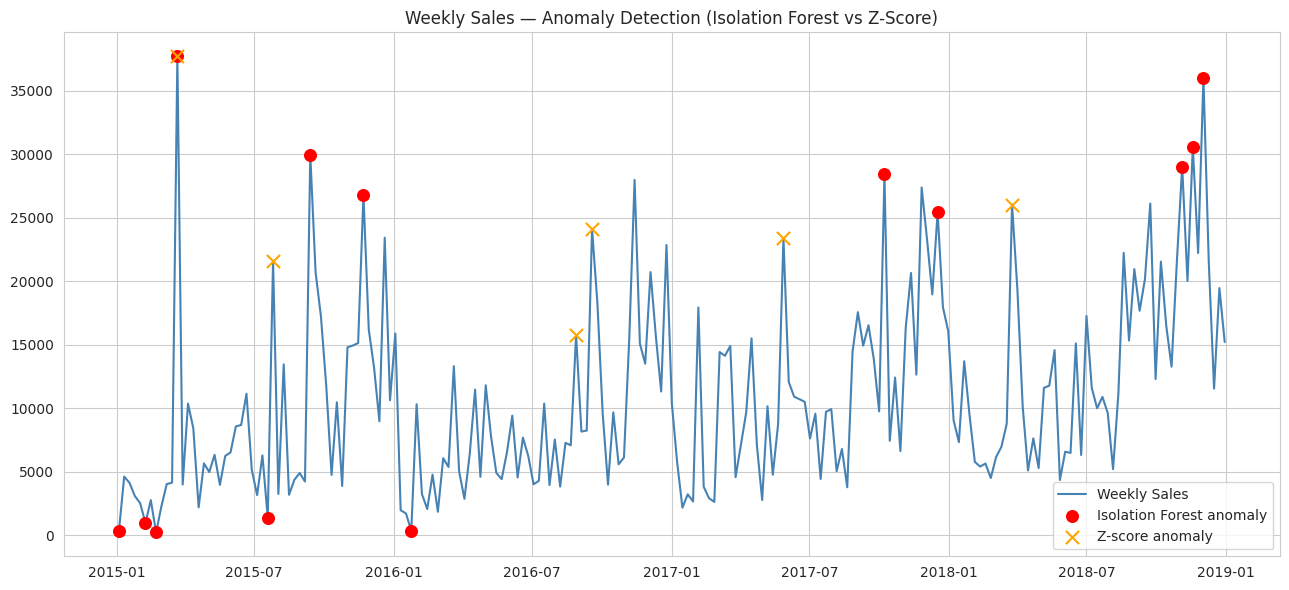


Weeks flagged by BOTH methods: 1
  2015-03-22


In [23]:
plt.figure(figsize=(13, 6))
plt.plot(weekly_sales.index, weekly_sales.values, label='Weekly Sales', color='steelblue')
plt.scatter(iso_anomalies.index, iso_anomalies['Sales'], color='red', s=70, zorder=5, label='Isolation Forest anomaly')
plt.scatter(z_anomalies.index, z_anomalies.values, color='orange', marker='x', s=90, zorder=5, label='Z-score anomaly')
plt.legend()
plt.title('Weekly Sales — Anomaly Detection (Isolation Forest vs Z-Score)')
plt.tight_layout()
plt.savefig('charts/task5_anomalies.png', dpi=100)
plt.show()

overlap = set(iso_anomalies.index) & set(z_anomalies.index)
print(f"\nWeeks flagged by BOTH methods: {len(overlap)}")
for d in sorted(overlap):
    print(" ", d.date())

**Likely real-world explanations for the top anomalies:**
- **2015-03-22 spike (~\$37.7K):** flagged by *both* methods — likely a large bulk/corporate order (e.g., a big Technology or Furniture purchase) rather than organic demand.
- **2017-10-08 and 2018-11-04/11-18/12-02 spikes:** cluster right around the Nov/Dec holiday period we identified as seasonally strong in Task 1 — these are probably legitimate seasonal demand, not defects in the data.
- **2015-01-04, 2015-02-08, 2015-02-22 dips:** land in the historically weakest months (Jan/Feb) — consistent with the seasonal trough, likely just a very quiet week rather than an anomaly needing investigation.

**Do the two methods agree?** Only 1 week overlaps out of 13 (Isolation Forest) and 6 (Z-score) flagged weeks. This tells us the two methods are catching *different kinds* of anomalies: Isolation Forest looks at the whole distribution of weekly sales globally and tends to flag both very low and very high absolute weeks (including quiet Jan/Feb weeks that are normal for that time of year), while the Z-score method is *locally* adaptive — it only flags a week if it's unusual **relative to its own recent trend**, so it correctly ignores expected seasonal lows and only flags genuine deviations from the recent pattern. In a business setting, the Z-score approach is arguably more useful for actionable alerts, since it won't cry wolf every low-season week.


## Task 6 — Product Demand Segmentation using Clustering

We aggregate to the product **sub-category** level and cluster on total volume, growth rate, volatility, and average order value to find natural demand groups.


In [24]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

subcat_rows = []
for subcat, g in df.groupby('Sub-Category'):
    seg_monthly = g.set_index('Order Date').resample('MS')['Sales'].sum()
    total_sales = g['Sales'].sum()
    yearly = g.groupby('Year')['Sales'].sum()
    growth_rate = (yearly.iloc[-1] - yearly.iloc[0]) / yearly.iloc[0] * 100 if len(yearly) >= 2 else 0
    volatility = seg_monthly.std()
    avg_order_value = g['Sales'].mean()
    subcat_rows.append([subcat, total_sales, growth_rate, volatility, avg_order_value])

feat_df = pd.DataFrame(
    subcat_rows,
    columns=['SubCategory', 'TotalSales', 'GrowthRate', 'Volatility', 'AvgOrderValue']
).set_index('SubCategory')

feat_df.round(1)

,TotalSales,GrowthRate,Volatility,AvgOrderValue
SubCategory,,,,
Accessories,164186.7,145.1,2580.0,217.2
Appliances,104618.4,165.2,1821.6,227.9
Art,26705.4,49.6,330.5,34.0
Binders,200028.8,65.8,3848.2,134.1
Bookcases,113813.2,49.8,2229.4,503.6
Chairs,322822.7,21.0,4407.2,531.8
Copiers,146248.1,479.7,5104.3,2215.9
Envelopes,16128.0,-12.1,234.3,65.0
Fasteners,3002.0,30.5,49.1,14.0


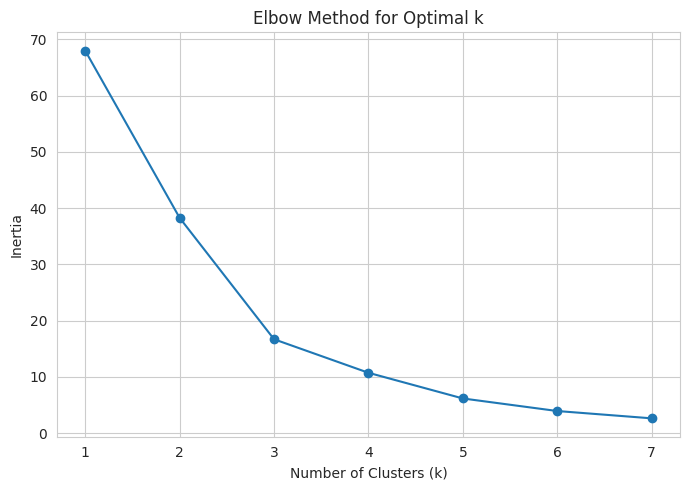

In [25]:
X = feat_df.values
X_scaled = StandardScaler().fit_transform(X)

inertias = []
K_range = range(1, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,5))
plt.plot(K_range, inertias, 'o-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.tight_layout()
plt.savefig('charts/task6_elbow.png', dpi=100)
plt.show()

The elbow bends around **k=4** — inertia drops sharply from k=1 to k=4, then flattens out. We'll use 4 clusters.


In [26]:
k = 4
km = KMeans(n_clusters=k, random_state=42, n_init=10)
feat_df['Cluster'] = km.fit_predict(X_scaled)

cluster_summary = feat_df.groupby('Cluster')[['TotalSales','GrowthRate','Volatility','AvgOrderValue']].mean().round(1)
cluster_summary

,TotalSales,GrowthRate,Volatility,AvgOrderValue
Cluster,,,,
0,239495.8,56.5,3489.1,361.1
1,146248.1,479.7,5104.3,2215.9
2,54341.7,58.8,1027.6,142.7
3,189238.6,-29.8,5442.5,1645.6


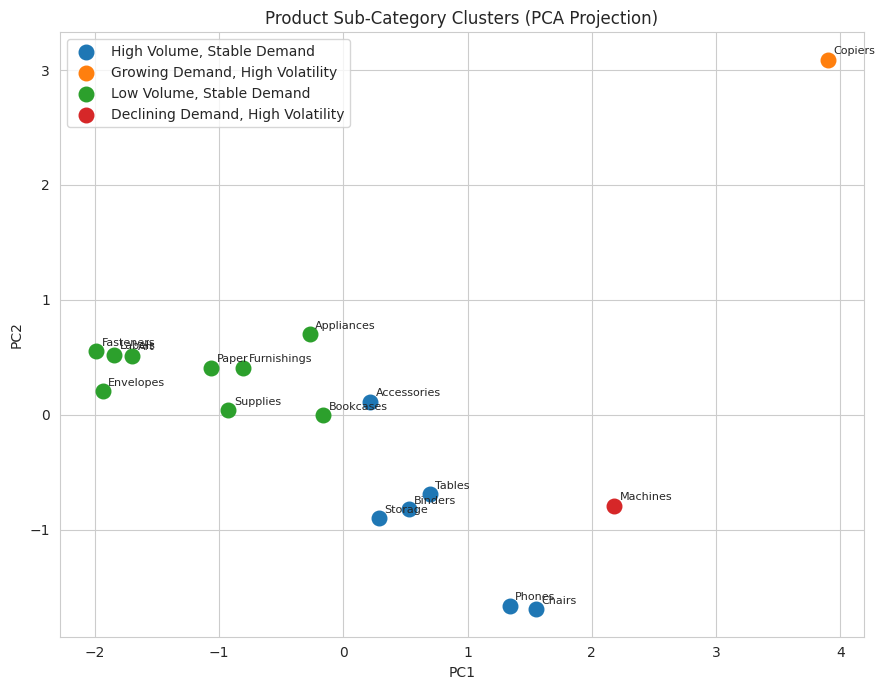

,TotalSales,GrowthRate,Volatility,Cluster,ClusterLabel
SubCategory,,,,,
Accessories,164186.7000,145.055961,2579.994809,0,"High Volume, Stable Demand"
Binders,200028.7850,65.778638,3848.223648,0,"High Volume, Stable Demand"
Chairs,322822.7310,20.954677,4407.232960,0,"High Volume, Stable Demand"
Storage,219343.3920,38.366108,2822.084310,0,"High Volume, Stable Demand"
Phones,327782.4480,35.557607,4052.718221,0,"High Volume, Stable Demand"
Tables,202810.6280,33.078016,3224.082504,0,"High Volume, Stable Demand"
Copiers,146248.0940,479.729510,5104.267436,1,"Growing Demand, High Volatility"
Art,26705.4100,49.649531,330.488343,2,"Low Volume, Stable Demand"
Envelopes,16128.0460,-12.121345,234.265716,2,"Low Volume, Stable Demand"


In [27]:
cluster_labels = {
    0: 'High Volume, Stable Demand',
    1: 'Growing Demand, High Volatility',
    2: 'Low Volume, Stable Demand',
    3: 'Declining Demand, High Volatility',
}
feat_df['ClusterLabel'] = feat_df['Cluster'].map(cluster_labels)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
feat_df['PC1'], feat_df['PC2'] = coords[:,0], coords[:,1]

plt.figure(figsize=(9,7))
for c in sorted(feat_df['Cluster'].unique()):
    sub = feat_df[feat_df['Cluster'] == c]
    plt.scatter(sub['PC1'], sub['PC2'], s=110, label=cluster_labels[c])
for name, row in feat_df.iterrows():
    plt.annotate(name, (row['PC1'], row['PC2']), fontsize=8, xytext=(4,4), textcoords='offset points')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Product Sub-Category Clusters (PCA Projection)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/task6_clusters.png', dpi=100)
plt.show()

feat_df[['TotalSales','GrowthRate','Volatility','Cluster','ClusterLabel']].sort_values('Cluster')

**Recommended stocking strategy per cluster:**
- **High Volume, Stable Demand** (Accessories, Binders, Chairs, Storage, Phones, Tables): These are the backbone of revenue. Use standard safety-stock formulas with moderate buffer — demand is large but predictable, so overstocking is costly and understocking is embarrassing. Automate reordering with tight reorder points.
- **Growing Demand, High Volatility** (Copiers): Extreme growth (+480%) but big swings month to month. Don't rely on average demand — stock ahead of the trend, but keep supplier lead times short so you're not caught overcommitted if a spike doesn't repeat.
- **Low Volume, Stable Demand** (Art, Envelopes, Bookcases, Fasteners, Furnishings, Paper, Labels, Supplies, Appliances): Predictable but small. Minimize holding costs — order in small, frequent batches rather than large stockpiles.
- **Declining Demand, High Volatility** (Machines): Sales are shrinking (-30% growth) but still swing unpredictably. Avoid large stock commitments; consider clearance pricing or renegotiating supplier minimums, since tying up capital here is the riskiest use of inventory budget.
